# FSCI — Flux-Surface Constrained Inversion, demo end-to-end

This notebook walks through the whole pipeline — Modules 1 through 7 —
against a **synthetic circular equilibrium**, so it runs anywhere
without needing a real TCABR g-file. A commented section near the top
shows how to swap in real TCABR data (Google Drive + GEQDSK) instead.

See the repository [README](../README.md) for the architecture
overview and the physics/engineering notes worth knowing before
modifying the underlying code.

**Two ways to run this notebook:**
- Already inside a clone of the repo with `fsci` installed (`pip install -e .`) — it will just work.
- Standalone (e.g. pasted into Google Colab) — the setup cell below will clone the repo and install it automatically.


In [1]:
# Setup: import fsci, or clone + install it if not already available.
try:
    import fsci
except ImportError:
    import sys, subprocess
    REPO_URL = "https://github.com/YOUR_USERNAME/tcabr-fsci.git"  # TODO: update once published
    subprocess.run(["git", "clone", REPO_URL], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-e", "tcabr-fsci[interactive]"], check=True)
    sys.path.insert(0, "tcabr-fsci/src")
    import fsci

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

print(f"fsci version: {fsci.__version__}")


fsci version: 0.1.0


## 0. Optional — using real TCABR data instead

The cell below is inert (fully commented) — it documents how to point
the pipeline at a real GEQDSK file from Google Drive instead of the
synthetic equilibrium used in the rest of this notebook. Uncomment
and adapt paths if you have access to the lab's data folder.

**Note:** as of this writing, the 32-channel hardware impact
parameters (`S_HARDWARE`) used elsewhere in the project are still a
synthetic placeholder, not the real Zemax-derived values — see the
README "Status" section.


In [2]:
# from google.colab import drive
# drive.mount('/content/drive')
#
# DATA_DIR = '/content/drive/MyDrive/TORAX-TCABR/data/'
# eq = fsci.load_equilibrium(DATA_DIR + 'g000000.eqdsk')
#
# XC, YC = 0.35, -0.875
# S_HARDWARE = ...  # real per-channel impact parameters, once available
# optics = fsci.build_optical_geometry(XC, YC, S_HARDWARE)


## 1. Quickstart — synthetic equilibrium and optics

Everything below runs without any external data file.


In [3]:
eq = fsci.build_synthetic_equilibrium()
optics = fsci.build_synthetic_optics(eq, n_channels=12)
grid = fsci.build_flux_grid(n_shells=20)

print(f"Magnetic axis: R = {eq.R_axis:.3f} m, Z = {eq.Z_axis:.3f} m")
print(f"Channels: {len(optics.sightlines)}, flux shells: {grid.n_shells}")


Magnetic axis: R = 0.600 m, Z = 0.000 m
Channels: 12, flux shells: 20


## 2. Module 2 — magnetic equilibrium

`psi_N` contours, LCFS, limiter, magnetic axis and geometric centre.
(For this synthetic case the equilibrium is a simple concentric
circle, so axis and geometric centre coincide — a real TCABR
equilibrium would show a visible Shafranov shift between them.)


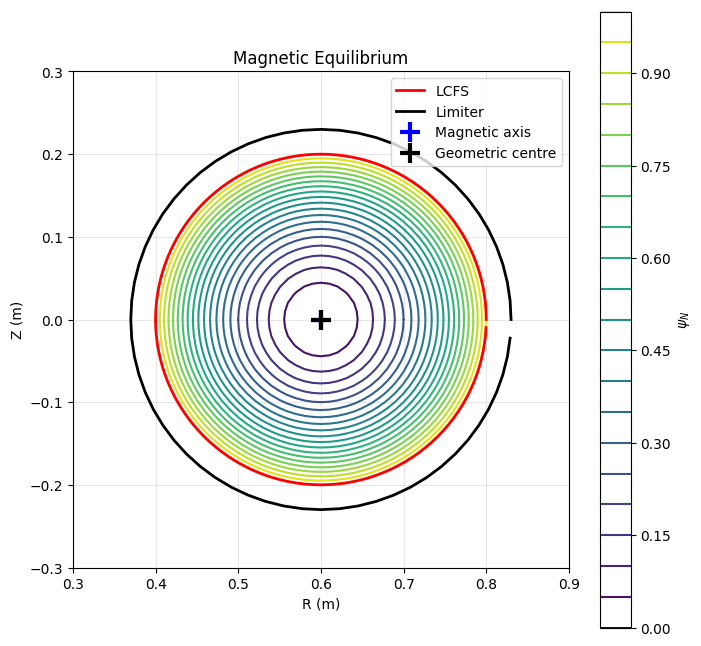

In [4]:
fig, ax = fsci.equilibrium.plot_equilibrium(eq)
plt.show()


## 3. Module 3 — flux-surface discretisation

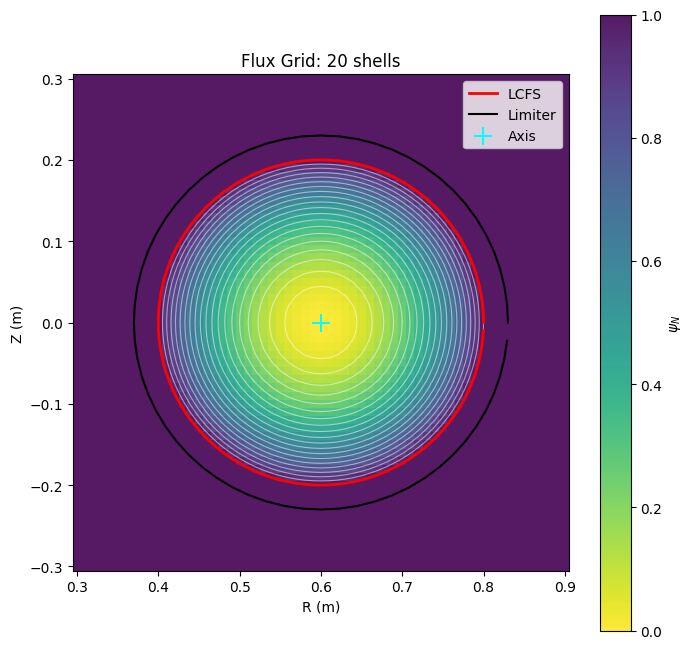

In [5]:
fig, ax = fsci.flux_grid.plot_flux_grid(eq, grid)
plt.show()


## 4. Module 4 — optical geometry (32-channel LOS fan, here shown with 12 synthetic channels)

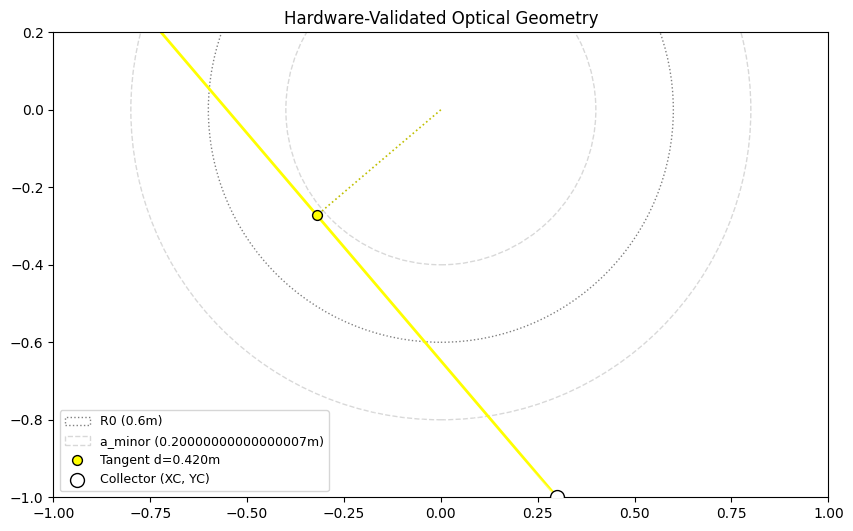

In [6]:
fig, ax = fsci.optics.plot_optical_geometry(
    optics, selected_id=1, r0=eq.R_axis, a_minor=float(np.max(eq.R_boundary) - eq.R_axis)
)
plt.show()


## 5. Module 5 — building the geometric matrix G

Continuous ray tracing through the equatorial plane, mapped onto the
real flux surfaces of the equilibrium — no onion-peeling, no
tangency assumption.


In [7]:
inv = fsci.build_geometric_matrix(optics, grid, eq)

print(f"G shape: {inv.data.shape}  (channels x shells)")
print(f"Adaptive integration step: {inv.ds * 1000:.3f} mm")
print(f"Max length in plasma: {inv.length_in_plasma.max():.4f} m")


G shape: (12, 20)  (channels x shells)
Adaptive integration step: 5.000 mm
Max length in plasma: 1.3650 m


## 6. Validation

Two distinct checks (see `fsci/validation.py` for exactly what each
one does and does not prove):


In [8]:
reg = fsci.run_regression_tests(optics, eq, inv)
alloc = fsci.run_independent_allocation_validation(optics, eq, inv)

print(f"Regression invariants passed: {reg.passed}")
for m in reg.messages:
    print(f"  note: {m}")

print(f"Independent allocation check passed: {alloc.passed} "
      f"(max divergence: {alloc.max_divergence:.2e} m)")


Regression invariants passed: True
Independent allocation check passed: True (max divergence: 2.22e-16 m)


## 7. Module 6 — visual validation dashboard

Static rendering for two channels (a central one and a peripheral
one). An interactive ipywidgets version — `launch_interactive_dashboard`
— is available for live Jupyter/Colab sessions with a channel slider,
but is not shown here because interactive widgets do not render in a
static GitHub preview of this notebook.


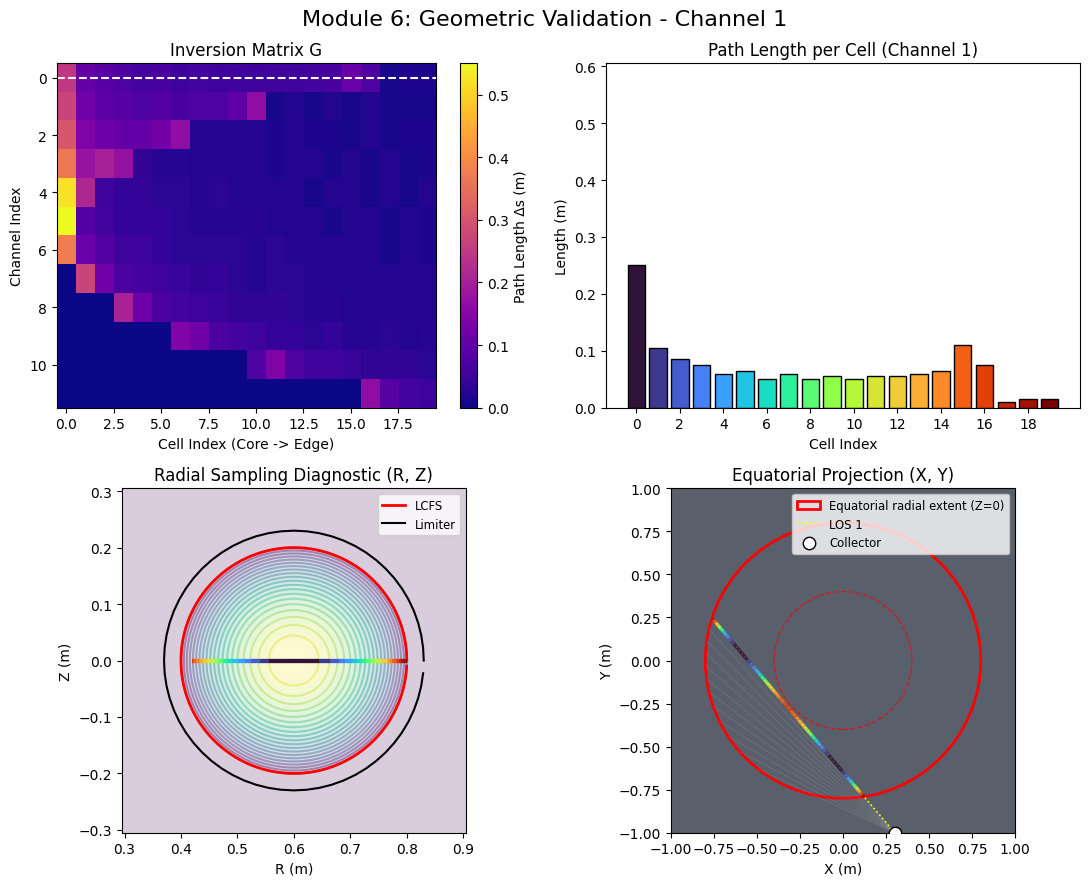

In [9]:
fig, axs = fsci.visualization.plot_inversion_validation(optics, grid, eq, inv, selected_channel=1)
plt.show()


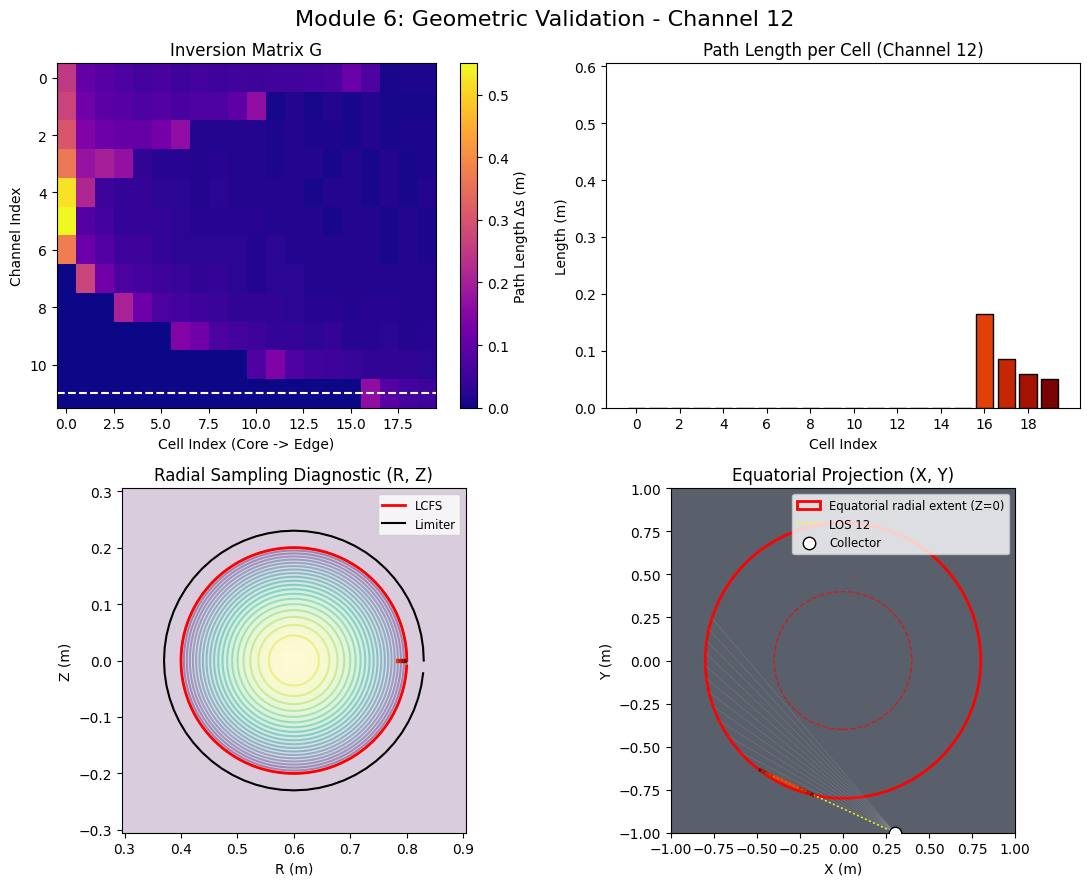

In [10]:
fig, axs = fsci.visualization.plot_inversion_validation(
    optics, grid, eq, inv, selected_channel=len(optics.sightlines)
)
plt.show()


In [11]:
# Live only (uncomment in an interactive Jupyter/Colab session):
# fsci.visualization.launch_interactive_dashboard(optics, grid, eq, inv)


## 8. Module 7 — inversion

We synthesise line-integrated signals from a known, smooth emissivity
profile, then try to recover it with the three regularised solvers.
This is a noise-free sanity check, not a claim about performance on
real noisy data.


In [12]:
true_emissivity = np.exp(-3 * grid.psi_centres)  # arbitrary smooth radial profile
signals = inv.data @ true_emissivity

results = {
    "NNLS": fsci.NNLSSolver().solve(inv.data, signals),
    "TSVD (k=6)": fsci.TSVDSolver(truncation_index=6).solve(inv.data, signals),
    "Tikhonov (\u03bb=0.05)": fsci.TikhonovSolver(lambda_param=0.05).solve(inv.data, signals),
}

for name, r in results.items():
    print(f"{name:<22s} chi^2 = {r.chi_square:.3e}")


NNLS                   chi^2 = 1.470e-32
TSVD (k=6)             chi^2 = 7.659e-06
Tikhonov (λ=0.05)      chi^2 = 1.275e-05


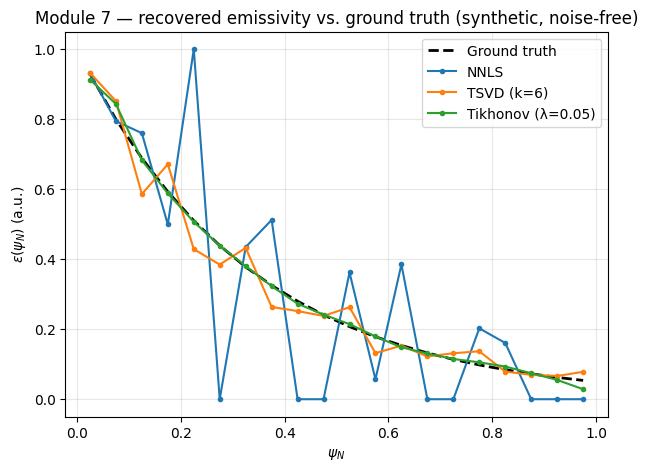

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(grid.psi_centres, true_emissivity, "k--", lw=2, label="Ground truth")
for name, r in results.items():
    ax.plot(grid.psi_centres, r.emissivity, marker="o", ms=3, label=name)
ax.set_xlabel(r"$\psi_N$")
ax.set_ylabel(r"$\varepsilon(\psi_N)$ (a.u.)")
ax.set_title("Module 7 — recovered emissivity vs. ground truth (synthetic, noise-free)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


## Limitations of this demo

- The equilibrium and optics here are synthetic (a plain circular
  case) — they exist to make this notebook runnable without lab data,
  not to represent TCABR's real, Shafranov-shifted equilibrium.
- The 32-channel hardware impact parameters (`S_HARDWARE`) used
  elsewhere in the project are still a placeholder, not the real
  Zemax-derived values.
- Inversion here is against noise-free synthetic signals; no claim is
  made about performance on real, noisy TCABR measurements.

See the repository README "Status" section for the current state of
these items.
